# Sistema de Trading Automatizado
## Análisis Técnico para Principiantes e Intermediarios

*Autor: wellcome peujio jiotsop foze*

---

Este notebook te guiará a través de los 5 indicadores técnicos fundamentales para tomar decisiones de trading. Aprenderás qué es cada indicador, cómo interpretarlo y cómo combinarlo en un sistema automatizado.

## Preparación: Importar Librerías y Datos

Primero, descargamos los datos de una acción real (Apple) para trabajar con ejemplos prácticos.

In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime

# Descargar datos de Apple (últimos 6 meses)
ticker = 'AAPL'
data = yf.download(ticker, period='6mo', progress=False)
close = data['Close']
close = data['Close'].squeeze()

print(f'Datos descargados: {len(data)} días de trading')
print(f'Precio actual: ${close.iloc[-1]:.2f}')
print(f'Precio mínimo: ${close.min():.2f}')
print(f'Precio máximo: ${close.max():.2f}')


Datos descargados: 124 días de trading
Precio actual: $249.94
Precio mínimo: $244.80
Precio máximo: $285.92


/tmp/ipykernel_431/3213484665.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, period='6mo', progress=False)


---

# Carrusel 1: RSI (Índice de Fuerza Relativa)

## ¿Qué es el RSI?

El RSI mide la **velocidad y magnitud de los cambios de precio**. Te ayuda a identificar si una acción está **sobrecomprada** (precio muy alto) o **sobrevendida** (precio muy bajo).

### Fórmula

$$RSI = 100 - \\frac{100}{1 + RS}$$

Donde $RS = \\frac{\\text{Ganancia Promedio}}{\\text{Pérdida Promedio}}$

### Interpretación

- **RSI < 30**: Acción sobrevendida → Posible compra
- **30 < RSI < 70**: Zona neutral → Sin señal clara
- **RSI > 70**: Acción sobrecomprada → Posible venta

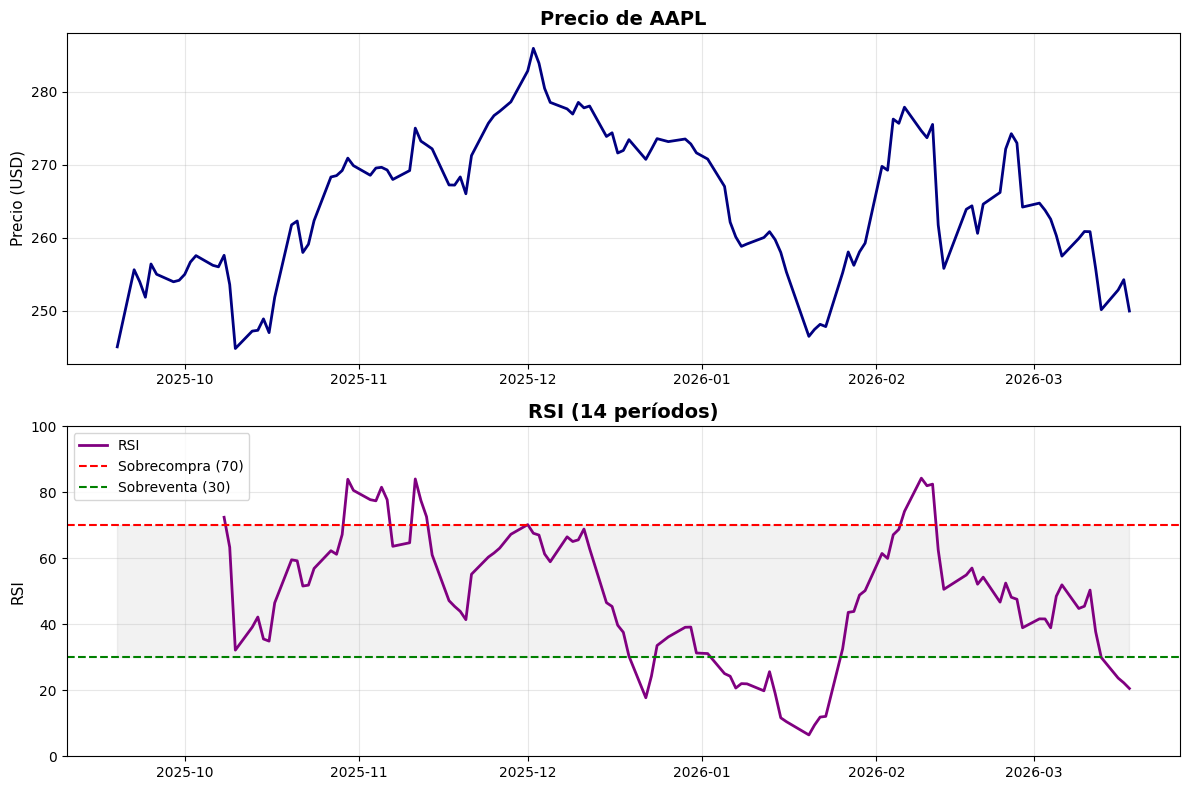

RSI actual: 20.54
Señal: SOBREVENDIDA - Posible oportunidad de compra


In [3]:
# Calcular RSI
def calcular_rsi(prices, period=14):
    delta = prices.diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=period).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=period).mean()
    rs = gain / loss
    rsi = 100 - (100 / (1 + rs))
    return rsi

rsi = calcular_rsi(close)

# Visualizar
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), gridspec_kw={'height_ratios': [1, 1]})

# Gráfico 1: Precio
ax1.plot(close, color='navy', linewidth=2)
ax1.set_title('Precio de AAPL', fontsize=14, fontweight='bold')
ax1.set_ylabel('Precio (USD)', fontsize=11)
ax1.grid(True, alpha=0.3)

# Gráfico 2: RSI
ax2.plot(rsi, color='purple', linewidth=2, label='RSI')
ax2.axhline(70, color='red', linestyle='--', linewidth=1.5, label='Sobrecompra (70)')
ax2.axhline(30, color='green', linestyle='--', linewidth=1.5, label='Sobreventa (30)')
ax2.fill_between(rsi.index, 30, 70, alpha=0.1, color='gray')
ax2.set_title('RSI (14 períodos)', fontsize=14, fontweight='bold')
ax2.set_ylabel('RSI', fontsize=11)
ax2.set_ylim(0, 100)
ax2.legend(loc='upper left')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f'RSI actual: {rsi.iloc[-1]:.2f}')
if rsi.iloc[-1] < 30:
    print('Señal: SOBREVENDIDA - Posible oportunidad de compra')
elif rsi.iloc[-1] > 70:
    print('Señal: SOBRECOMPRADA - Posible oportunidad de venta')
else:
    print('Señal: NEUTRAL - Sin señal clara del RSI')

---

# Carrusel 2: MACD (Convergencia/Divergencia de Medias Móviles)

## ¿Qué es el MACD?

El MACD mide el **momentum** (impulso) del precio. Combina dos medias móviles para identificar cambios de tendencia.

### Fórmula

$$MACD = EMA_{12}(Precio) - EMA_{26}(Precio)$$
$$Línea\ de\ Señal = EMA_9(MACD)$$
$$Histograma = MACD - Línea\ de\ Señal$$

### Interpretación

- **MACD cruza hacia arriba la línea de señal**: Señal de compra (momentum positivo)
- **MACD cruza hacia abajo la línea de señal**: Señal de venta (momentum negativo)
- **Histograma positivo**: Tendencia alcista
- **Histograma negativo**: Tendencia bajista

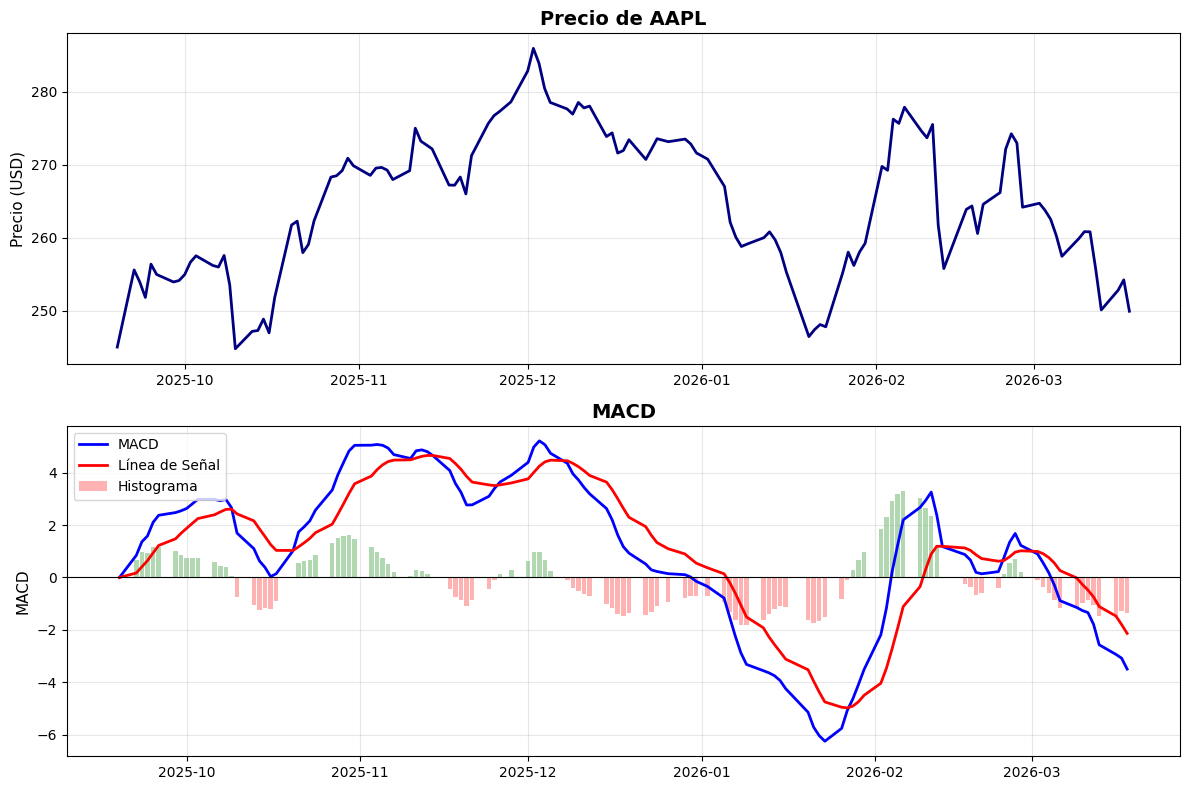

MACD actual: -3.4986
Línea de Señal: -2.1371
Histograma: -1.3615
Señal: MOMENTUM NEGATIVO - Tendencia bajista


In [4]:
# Calcular MACD
def calcular_macd(prices, fast=12, slow=26, signal=9):
    ema_fast = prices.ewm(span=fast, adjust=False).mean()
    ema_slow = prices.ewm(span=slow, adjust=False).mean()
    macd = ema_fast - ema_slow
    signal_line = macd.ewm(span=signal, adjust=False).mean()
    histogram = macd - signal_line
    return macd, signal_line, histogram

macd, signal_line, histogram = calcular_macd(close)

# Visualizar
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), gridspec_kw={'height_ratios': [1, 1]})

# Gráfico 1: Precio
ax1.plot(close, color='navy', linewidth=2)
ax1.set_title('Precio de AAPL', fontsize=14, fontweight='bold')
ax1.set_ylabel('Precio (USD)', fontsize=11)
ax1.grid(True, alpha=0.3)

# Gráfico 2: MACD
ax2.plot(macd, color='blue', linewidth=2, label='MACD')
ax2.plot(signal_line, color='red', linewidth=2, label='Línea de Señal')
colors = ['green' if h > 0 else 'red' for h in histogram]
ax2.bar(histogram.index, histogram, color=colors, alpha=0.3, label='Histograma')
ax2.axhline(0, color='black', linestyle='-', linewidth=0.8)
ax2.set_title('MACD', fontsize=14, fontweight='bold')
ax2.set_ylabel('MACD', fontsize=11)
ax2.legend(loc='upper left')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f'MACD actual: {macd.iloc[-1]:.4f}')
print(f'Línea de Señal: {signal_line.iloc[-1]:.4f}')
print(f'Histograma: {histogram.iloc[-1]:.4f}')
if histogram.iloc[-1] > 0:
    print('Señal: MOMENTUM POSITIVO - Tendencia alcista')
else:
    print('Señal: MOMENTUM NEGATIVO - Tendencia bajista')

---

# Carrusel 3: Bandas de Bollinger

## ¿Qué son las Bandas de Bollinger?

Las Bandas de Bollinger miden la **volatilidad** del precio. Consisten en tres líneas: una media central y dos bandas que se expanden o contraen según la volatilidad.

### Fórmula

$$Banda\ Superior = SMA_{20} + 2 \\times \\sigma$$
$$Banda\ Media = SMA_{20}$$
$$Banda\ Inferior = SMA_{20} - 2 \\times \\sigma$$

### Interpretación

- **Precio toca banda inferior**: Acción sobrevendida → Posible compra
- **Precio dentro de las bandas**: Comportamiento normal
- **Precio toca banda superior**: Acción sobrecomprada → Posible venta
- **Bandas se expanden**: Volatilidad aumenta
- **Bandas se contraen**: Volatilidad disminuye

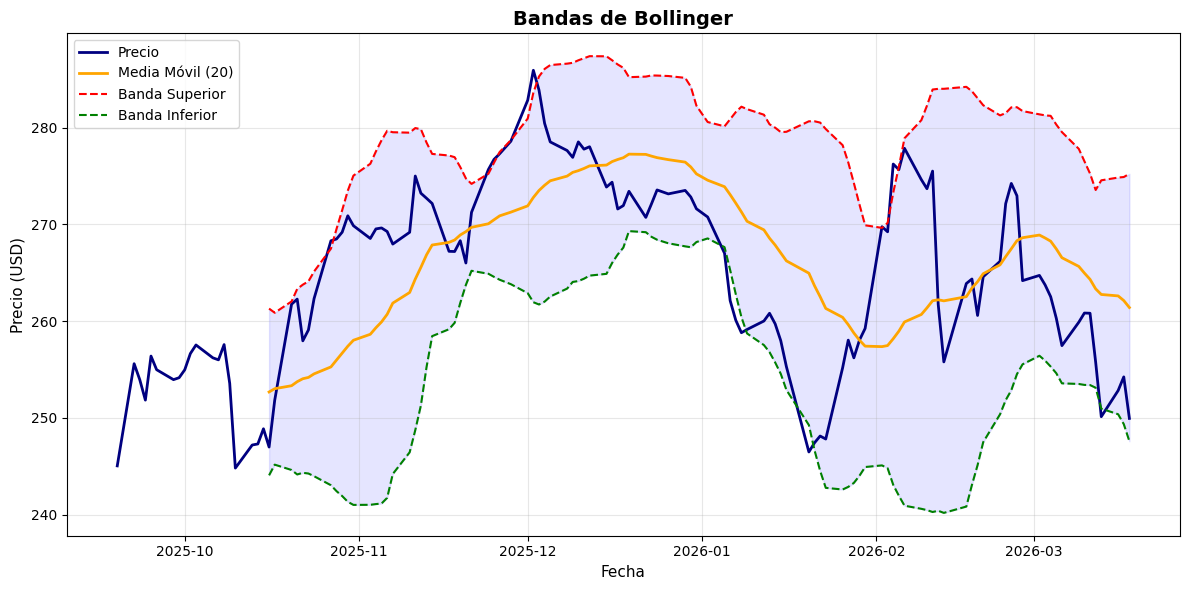

Precio actual: $249.94
Banda Superior: $275.22
Banda Inferior: $247.58
Señal: DENTRO DE BANDAS - Comportamiento normal


In [5]:
# Calcular Bandas de Bollinger
def calcular_bollinger(prices, period=20, std_dev=2):
    sma = prices.rolling(window=period).mean()
    std = prices.rolling(window=period).std()
    upper_band = sma + (std_dev * std)
    lower_band = sma - (std_dev * std)
    return upper_band, sma, lower_band

upper_band, sma, lower_band = calcular_bollinger(close)

# Visualizar
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(close, color='navy', linewidth=2, label='Precio')
ax.plot(sma, color='orange', linewidth=2, label='Media Móvil (20)')
ax.plot(upper_band, color='red', linestyle='--', linewidth=1.5, label='Banda Superior')
ax.plot(lower_band, color='green', linestyle='--', linewidth=1.5, label='Banda Inferior')
ax.fill_between(close.index, upper_band, lower_band, alpha=0.1, color='blue')

ax.set_title('Bandas de Bollinger', fontsize=14, fontweight='bold')
ax.set_ylabel('Precio (USD)', fontsize=11)
ax.set_xlabel('Fecha', fontsize=11)
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

current_price = close.iloc[-1]
current_upper = upper_band.iloc[-1]
current_lower = lower_band.iloc[-1]

print(f'Precio actual: ${current_price:.2f}')
print(f'Banda Superior: ${current_upper:.2f}')
print(f'Banda Inferior: ${current_lower:.2f}')

if current_price < current_lower:
    print('Señal: SOBREVENDIDA - Posible oportunidad de compra')
elif current_price > current_upper:
    print('Señal: SOBRECOMPRADA - Posible oportunidad de venta')
else:
    print('Señal: DENTRO DE BANDAS - Comportamiento normal')

---

# Carrusel 4: Fibonacci

## ¿Qué es el Retroceso de Fibonacci?

Los retrocesos de Fibonacci identifican **niveles de soporte y resistencia** basados en la secuencia de Fibonacci. Estos niveles son donde el precio tiende a rebotar.

### Niveles Clave de Fibonacci

- **0%**: Máximo histórico
- **23.6%**: Primer retroceso
- **38.2%**: Retroceso moderado
- **50%**: Punto medio
- **61.8%**: Retroceso fuerte (Golden Ratio)
- **100%**: Mínimo histórico

### Interpretación

- **Precio cerca del 61.8%**: Soporte/Resistencia fuerte → Posible rebote
- **Precio cerca del 50%**: Punto de equilibrio
- **Precio cerca del 38.2%**: Soporte/Resistencia moderado

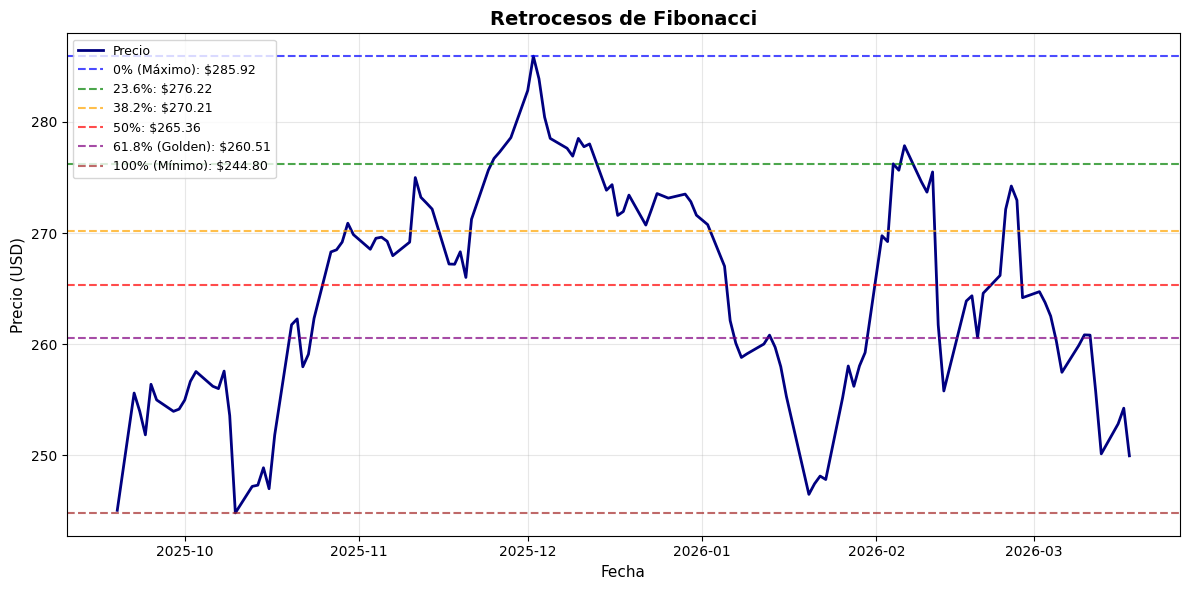

Niveles de Fibonacci:
0% (Máximo): $285.92
23.6%: $276.22
38.2%: $270.21
50%: $265.36
61.8% (Golden): $260.51
100% (Mínimo): $244.80


In [6]:
# Calcular Fibonacci
def calcular_fibonacci(prices):
    max_price = prices.max()
    min_price = prices.min()
    diff = max_price - min_price

    levels = {
        '0% (Máximo)': max_price,
        '23.6%': max_price - 0.236 * diff,
        '38.2%': max_price - 0.382 * diff,
        '50%': max_price - 0.5 * diff,
        '61.8% (Golden)': max_price - 0.618 * diff,
        '100% (Mínimo)': min_price
    }
    return levels

fib_levels = calcular_fibonacci(close)

# Visualizar
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(close, color='navy', linewidth=2, label='Precio')

colors = ['blue', 'green', 'orange', 'red', 'purple', 'brown']
for i, (level_name, level_price) in enumerate(fib_levels.items()):
    ax.axhline(level_price, linestyle='--', linewidth=1.5, alpha=0.7,
               color=colors[i], label=f'{level_name}: ${level_price:.2f}')

ax.set_title('Retrocesos de Fibonacci', fontsize=14, fontweight='bold')
ax.set_ylabel('Precio (USD)', fontsize=11)
ax.set_xlabel('Fecha', fontsize=11)
ax.legend(loc='upper left', fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print('Niveles de Fibonacci:')
for level_name, level_price in fib_levels.items():
    print(f'{level_name}: ${level_price:.2f}')

---

# Carrusel 5: Sistema de Trading Automatizado

## Combinando Todos los Indicadores

Ahora combinamos los 4 indicadores en un **sistema de puntuación** que genera señales de trading automáticas.

### Sistema de Puntuación (0-100)

| Indicador | Puntos | Criterio |
|-----------|--------|----------|
| **RSI** | 30 | <30: +30, 30-70: +15, >70: 0 |
| **MACD** | 25 | Cruce alcista: +25, Histograma positivo: +15 |
| **Bollinger** | 25 | Toca banda inferior: +25, Dentro bandas: +15 |
| **Fibonacci** | 20 | Cerca 61.8%: +20, Cerca 50%: +15, Cerca 38.2%: +5 |

### Señales de Trading

- **80-100**: COMPRA FUERTE ✓
- **60-79**: COMPRA ✓
- **40-59**: NEUTRAL ○
- **20-39**: VENDE ✗
- **0-19**: VENDE FUERTE ✗

RESULTADO DEL SISTEMA DE TRADING
Score Total: 45/100
Señal: NEUTRAL


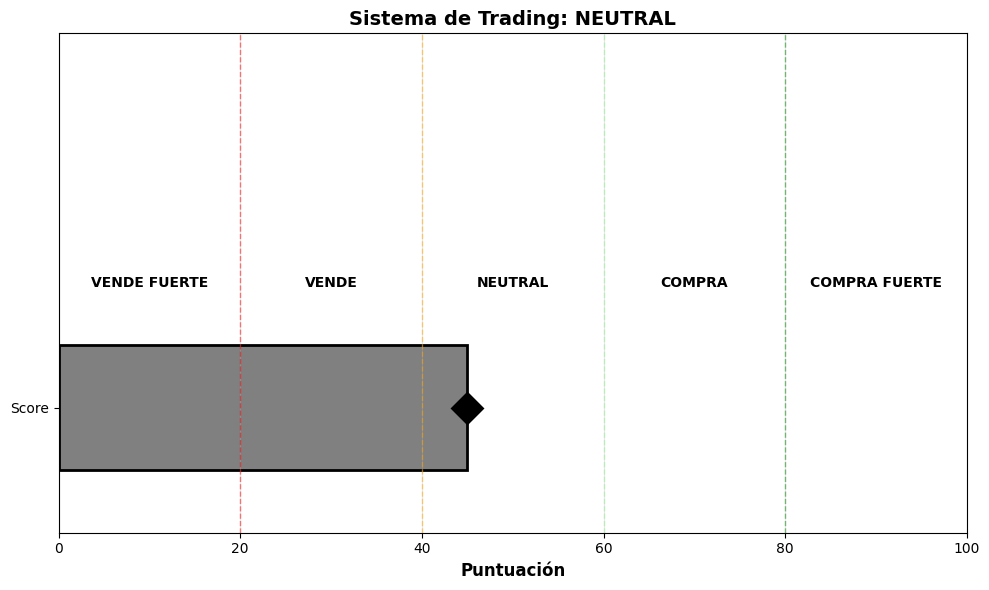

In [7]:
# Sistema de Puntuación
def calcular_score_sistema(rsi, macd, signal_line, close, upper_band, lower_band, fib_levels):
    score = 0

    # RSI (30 puntos)
    rsi_actual = rsi.iloc[-1]
    if rsi_actual < 30:
        score += 30
    elif 30 <= rsi_actual <= 70:
        score += 15

    # MACD (25 puntos)
    if macd.iloc[-1] > signal_line.iloc[-1] and macd.iloc[-2] <= signal_line.iloc[-2]:
        score += 25
    elif histogram.iloc[-1] > 0:
        score += 15

    # Bollinger (25 puntos)
    current_price = close.iloc[-1]
    if current_price < lower_band.iloc[-1]:
        score += 25
    elif lower_band.iloc[-1] <= current_price <= upper_band.iloc[-1]:
        score += 15

    # Fibonacci (20 puntos)
    fib_618 = fib_levels['61.8% (Golden)']
    fib_50 = fib_levels['50%']
    fib_382 = fib_levels['38.2%']

    rango = fib_levels['0% (Máximo)'] - fib_levels['100% (Mínimo)']

    if abs(current_price - fib_618) < rango * 0.05:
        score += 20
    elif abs(current_price - fib_50) < rango * 0.05:
        score += 15
    elif abs(current_price - fib_382) < rango * 0.05:
        score += 5

    return score

def obtener_señal(score):
    if score >= 80:
        return 'COMPRA FUERTE', 'green'
    elif score >= 60:
        return 'COMPRA', 'lightgreen'
    elif score >= 40:
        return 'NEUTRAL', 'gray'
    elif score >= 20:
        return 'VENDE', 'lightyellow'
    else:
        return 'VENDE FUERTE', 'red'

# Calcular score
score_total = calcular_score_sistema(rsi, macd, signal_line, close, upper_band, lower_band, fib_levels)
señal, color = obtener_señal(score_total)

# Mostrar resultado
print('='*50)
print('RESULTADO DEL SISTEMA DE TRADING')
print('='*50)
print(f'Score Total: {score_total}/100')
print(f'Señal: {señal}')
print('='*50)

# Visualizar
fig, ax = plt.subplots(figsize=(10, 6))

# Barra de puntuación
ax.barh(['Score'], [score_total], color=color, height=0.5, edgecolor='black', linewidth=2)
ax.set_xlim(0, 100)
ax.set_xlabel('Puntuación', fontsize=12, fontweight='bold')
ax.set_title(f'Sistema de Trading: {señal}', fontsize=14, fontweight='bold')

# Añadir líneas de referencia
ax.axvline(20, color='red', linestyle='--', alpha=0.5, linewidth=1)
ax.axvline(40, color='orange', linestyle='--', alpha=0.5, linewidth=1)
ax.axvline(60, color='lightgreen', linestyle='--', alpha=0.5, linewidth=1)
ax.axvline(80, color='green', linestyle='--', alpha=0.5, linewidth=1)

# Texto con etiquetas
ax.text(10, 0.5, 'VENDE FUERTE', ha='center', va='center', fontweight='bold')
ax.text(30, 0.5, 'VENDE', ha='center', va='center', fontweight='bold')
ax.text(50, 0.5, 'NEUTRAL', ha='center', va='center', fontweight='bold')
ax.text(70, 0.5, 'COMPRA', ha='center', va='center', fontweight='bold')
ax.text(90, 0.5, 'COMPRA FUERTE', ha='center', va='center', fontweight='bold')

# Marcador del score
ax.plot(score_total, 0, 'D', markersize=15, color='black', markeredgewidth=2)

ax.set_ylim(-0.5, 1.5)
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

## Resumen de Indicadores

Aquí está el análisis completo de todos los indicadores:

In [8]:
# Crear tabla de resumen
resumen = pd.DataFrame({
    'Indicador': ['RSI', 'MACD', 'Bollinger', 'Fibonacci'],
    'Valor Actual': [
        f'{rsi.iloc[-1]:.2f}',
        f'{macd.iloc[-1]:.4f}',
        f'${close.iloc[-1]:.2f}',
        f'${close.iloc[-1]:.2f}'
    ],
    'Interpretación': [
        'Sobrevendida' if rsi.iloc[-1] < 30 else ('Sobrecomprada' if rsi.iloc[-1] > 70 else 'Neutral'),
        'Positivo' if histogram.iloc[-1] > 0 else 'Negativo',
        'Bajo banda inf.' if close.iloc[-1] < lower_band.iloc[-1] else ('Sobre banda sup.' if close.iloc[-1] > upper_band.iloc[-1] else 'Dentro bandas'),
        'Cerca 61.8%' if abs(close.iloc[-1] - fib_levels['61.8% (Golden)']) < (fib_levels['0% (Máximo)'] - fib_levels['100% (Mínimo)']) * 0.05 else 'Otros niveles'
    ]
})

print('\nRESUMEN DE INDICADORES')
print('='*70)
print(resumen.to_string(index=False))
print('='*70)


RESUMEN DE INDICADORES
Indicador Valor Actual Interpretación
      RSI        20.54   Sobrevendida
     MACD      -3.4986       Negativo
Bollinger      $249.94  Dentro bandas
Fibonacci      $249.94  Otros niveles


---

## Conclusión

Felicidades! Has aprendido los 5 carruseles del análisis técnico:

1. **RSI**: Identifica sobrecompra/sobreventa
2. **MACD**: Detecta cambios de momentum
3. **Bandas de Bollinger**: Mide volatilidad y extremos
4. **Fibonacci**: Encuentra soportes y resistencias
5. **Sistema Automatizado**: Combina todo en una señal clara

### Próximos Pasos

- Practica con diferentes acciones
- Ajusta los parámetros según tu estrategia
- Combina estos indicadores con análisis fundamental
- Nunca operes sin gestión de riesgo

**Recuerda**: El trading conlleva riesgo. Usa estos indicadores como herramientas de apoyo, no como garantías de ganancia.